In [8]:
# Ensure datasets library is installed and load the dataset as in EDA notebook
%pip install datasets -q
from datasets import load_dataset

dataset = load_dataset("millat/e-commerce-orders")
df = dataset['train'].to_pandas()
df.head()

Note: you may need to restart the kernel to use updated packages.


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


# 3. Unsupervised Clustering: Customer Behavior
This notebook implements k-Means clustering, determines the optimal number of clusters, and analyzes cluster centroids for business insights.

## 1. Import Required Libraries
We import all necessary libraries for clustering, visualization, and analysis.

In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## 2. Load Data and Preprocessing Pipeline
We load the cleaned dataset and the preprocessing pipeline from previous steps.

In [11]:
# Load cleaned data (repeat cleaning steps for reproducibility)
drop_cols = ['order_id', 'customer_id', 'product_id', 'shipping_address', 'billing_address']
df_clean = df.drop(columns=drop_cols)
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping_date'])
for col in ['order_date', 'shipping_date']:
    df_clean[f'{col}_year'] = df_clean[col].dt.year
    df_clean[f'{col}_month'] = df_clean[col].dt.month
    df_clean[f'{col}_day'] = df_clean[col].dt.day
    df_clean[f'{col}_hour'] = df_clean[col].dt.hour
df_clean['days_to_ship'] = (df_clean['shipping_date'] - df_clean['order_date']).dt.days
df_clean = df_clean.drop(columns=['order_date', 'shipping_date'])
df_clean = df_clean.fillna({'days_to_ship': df_clean['days_to_ship'].median()})
df_clean = df_clean.dropna()

# Load preprocessing pipeline
preprocessor = joblib.load('../artifacts/preprocessing_pipeline.joblib')

## 3. Prepare Features for Clustering
We select and preprocess features for k-means clustering.

In [12]:
# Exclude target columns for unsupervised learning
X_cluster = df_clean.drop(columns=['customer_segment', 'delivery_status'])
X_cluster_processed = preprocessor.transform(X_cluster)
X_cluster_processed.shape

(10000, 29)

## 4. Select Number of Clusters (k)
We use the Elbow Method and Silhouette Score to determine the optimal number of clusters.

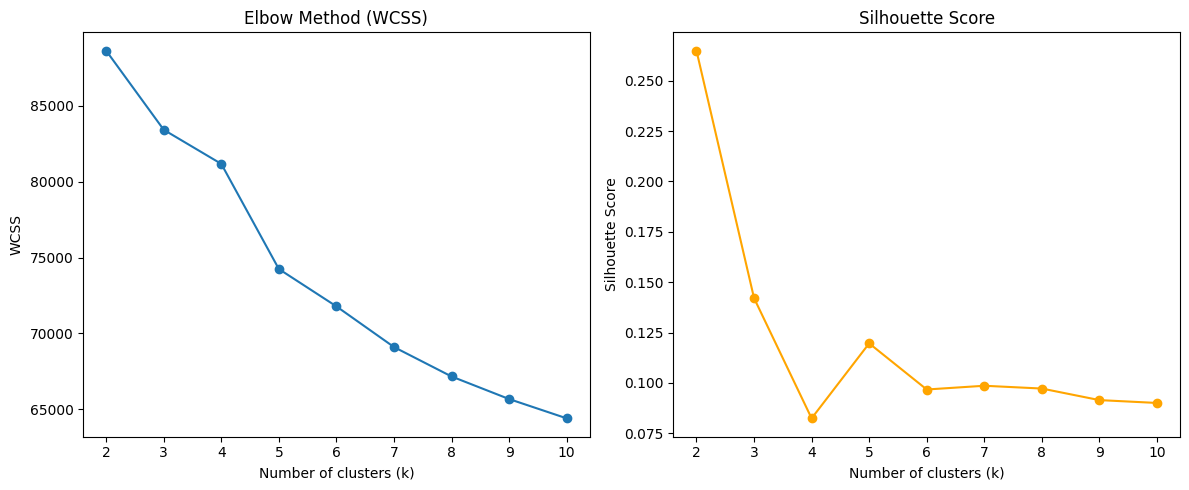

Saved: ../artifacts/elbow_and_silhouette_plot.png


In [13]:
# Elbow method and silhouette score
wcss = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_processed)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_processed, kmeans.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
import os
os.makedirs('../artifacts', exist_ok=True)
plt.savefig('../artifacts/elbow_and_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../artifacts/elbow_and_silhouette_plot.png")

### Elbow and Silhouette Analysis
This cell tests multiple k values and plots WCSS and silhouette score to help choose the best cluster count.

## 5. Apply k-Means Clustering
We fit k-means with the selected number of clusters and analyze the results.

In [14]:
# Choose k based on elbow/silhouette (example: k=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_cluster_processed)
df_clean['cluster'] = clusters

# Cluster sizes
print(df_clean['cluster'].value_counts())

cluster
2    3516
0    3436
3    1551
1    1497
Name: count, dtype: int64


## 6. Cluster Visualization
We project clustered records into 2D using PCA and plot customer segments as a scatter chart.

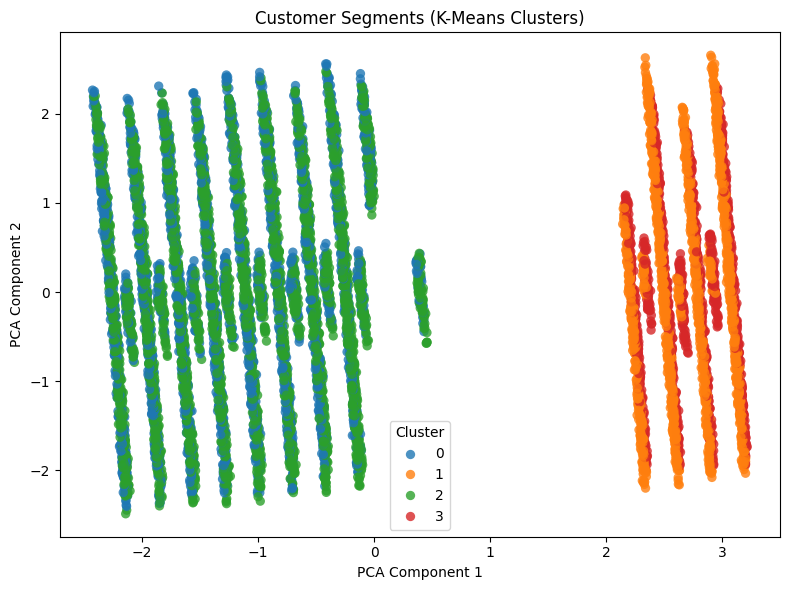

Saved: ../artifacts/customer_segments_scatter.png


In [15]:
# 2D cluster visualization using PCA projection
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_cluster_2d = pca.fit_transform(X_cluster_processed)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_cluster_2d[:, 0],
    y=X_cluster_2d[:, 1],
    hue=df_clean['cluster'],
    palette='tab10',
    s=45,
    alpha=0.8,
    edgecolor='none'
 )
plt.title('Customer Segments (K-Means Clusters)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
import os
os.makedirs('../artifacts', exist_ok=True)
plt.savefig('../artifacts/customer_segments_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../artifacts/customer_segments_scatter.png")

### Cluster Visualization
This cell projects the customer data into two dimensions with PCA and colors the points by cluster label.

## 7. Cluster Interpretation
We analyze the centroids and feature distributions for each cluster to extract business insights.

In [16]:
# Analyze cluster centroids (in original feature space is complex due to encoding)
# Instead, analyze summary statistics for each cluster
for c in range(k):
    print(f"\nCluster {c} summary:")
    display(df_clean[df_clean['cluster'] == c].describe(include='all'))


Cluster 0 summary:


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_year,order_date_month,order_date_day,order_date_hour,shipping_date_year,shipping_date_month,shipping_date_day,shipping_date_hour,days_to_ship,cluster
count,3436,3436.000000,3436.000000,3436,3436,3436,3436,3436,3436.0,3436.000000,3436.000000,3436.0,3436.000000,3436.000000,3436.000000,3436.0,3436.000000,3436.0
unique,6,NaN,NaN,4,5,3,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Beauty,NaN,NaN,Delivered,Apple Pay,Tablet,Social,VIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,648,NaN,NaN,2450,714,1159,895,1821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,128.857998,2.155122,NaN,NaN,NaN,NaN,NaN,2024.0,8.384459,16.213912,14.0,2024.009604,8.393772,16.304424,14.0,3.890861,0.0
std,NaN,71.611122,1.261029,NaN,NaN,NaN,NaN,NaN,0.0,2.416774,8.794860,0.0,0.097543,2.478333,9.000462,0.0,2.007850,0.0
min,NaN,5.060000,1.000000,NaN,NaN,NaN,NaN,NaN,2024.0,4.000000,1.000000,14.0,2024.000000,1.000000,1.000000,14.0,1.000000,0.0
25%,NaN,66.802500,1.000000,NaN,NaN,NaN,NaN,NaN,2024.0,6.000000,8.000000,14.0,2024.000000,6.000000,8.000000,14.0,2.000000,0.0
50%,NaN,127.985000,2.000000,NaN,NaN,NaN,NaN,NaN,2024.0,8.000000,17.000000,14.0,2024.000000,8.000000,17.000000,14.0,4.000000,0.0
75%,NaN,191.125000,3.000000,NaN,NaN,NaN,NaN,NaN,2024.0,10.000000,24.000000,14.0,2024.000000,10.000000,24.000000,14.0,6.000000,0.0



Cluster 1 summary:


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_year,order_date_month,order_date_day,order_date_hour,shipping_date_year,shipping_date_month,shipping_date_day,shipping_date_hour,days_to_ship,cluster
count,1497,1497.000000,1497.000000,1497,1497,1497,1497,1497,1497.0,1497.000000,1497.000000,1497.0,1497.0,1497.000000,1497.000000,1497.0,1497.000000,1497.0
unique,6,NaN,NaN,4,5,3,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Toys,NaN,NaN,Delivered,Apple Pay,Desktop,Email,VIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,273,NaN,NaN,1039,335,508,406,762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,233.640254,2.104208,NaN,NaN,NaN,NaN,NaN,2025.0,2.367401,13.933200,14.0,2025.0,2.419506,14.726119,14.0,2.350033,1.0
std,NaN,139.665816,1.234460,NaN,NaN,NaN,NaN,NaN,0.0,1.069737,8.457084,0.0,0.0,1.078023,8.180766,0.0,1.011492,0.0
min,NaN,5.240000,1.000000,NaN,NaN,NaN,NaN,NaN,2025.0,1.000000,1.000000,14.0,2025.0,1.000000,1.000000,14.0,1.000000,1.0
25%,NaN,115.570000,1.000000,NaN,NaN,NaN,NaN,NaN,2025.0,1.000000,7.000000,14.0,2025.0,1.000000,8.000000,14.0,1.000000,1.0
50%,NaN,223.430000,2.000000,NaN,NaN,NaN,NaN,NaN,2025.0,2.000000,13.000000,14.0,2025.0,2.000000,14.000000,14.0,2.000000,1.0
75%,NaN,350.800000,3.000000,NaN,NaN,NaN,NaN,NaN,2025.0,3.000000,21.000000,14.0,2025.0,3.000000,21.000000,14.0,3.000000,1.0



Cluster 2 summary:


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_year,order_date_month,order_date_day,order_date_hour,shipping_date_year,shipping_date_month,shipping_date_day,shipping_date_hour,days_to_ship,cluster
count,3516,3516.000000,3516.000000,3516,3516,3516,3516,3516,3516.0,3516.000000,3516.000000,3516.0,3516.000000,3516.000000,3516.000000,3516.0,3516.000000,3516.0
unique,6,NaN,NaN,4,5,3,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Electronics,NaN,NaN,Delivered,Google Pay,Desktop,Paid Search,VIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,632,NaN,NaN,2448,715,1222,904,1754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,372.680316,2.088453,NaN,NaN,NaN,NaN,NaN,2024.0,8.208476,16.418373,14.0,2024.020193,8.123151,15.694539,14.0,4.074516,2.0
std,NaN,71.529402,1.244446,NaN,NaN,NaN,NaN,NaN,0.0,2.461203,8.941816,0.0,0.140681,2.591796,8.980870,0.0,1.999323,0.0
min,NaN,220.760000,1.000000,NaN,NaN,NaN,NaN,NaN,2024.0,4.000000,1.000000,14.0,2024.000000,1.000000,1.000000,14.0,1.000000,2.0
25%,NaN,312.402500,1.000000,NaN,NaN,NaN,NaN,NaN,2024.0,6.000000,9.000000,14.0,2024.000000,6.000000,8.000000,14.0,2.000000,2.0
50%,NaN,372.785000,2.000000,NaN,NaN,NaN,NaN,NaN,2024.0,8.000000,17.000000,14.0,2024.000000,8.000000,16.000000,14.0,4.000000,2.0
75%,NaN,433.740000,3.000000,NaN,NaN,NaN,NaN,NaN,2024.0,10.000000,24.000000,14.0,2024.000000,10.000000,24.000000,14.0,6.000000,2.0



Cluster 3 summary:


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_year,order_date_month,order_date_day,order_date_hour,shipping_date_year,shipping_date_month,shipping_date_day,shipping_date_hour,days_to_ship,cluster
count,1551,1551.000000,1551.000000,1551,1551,1551,1551,1551,1551.0,1551.000000,1551.000000,1551.0,1551.0,1551.000000,1551.000000,1551.0,1551.000000,1551.0
unique,6,NaN,NaN,4,5,3,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Clothing,NaN,NaN,Delivered,PayPal,Mobile,Paid Search,VIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,276,NaN,NaN,1110,339,524,413,812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,272.499858,2.159252,NaN,NaN,NaN,NaN,NaN,2025.0,2.325596,14.858156,14.0,2025.0,2.486783,15.745970,14.0,5.710509,3.0
std,NaN,140.641162,1.279028,NaN,NaN,NaN,NaN,NaN,0.0,1.084368,8.574034,0.0,0.0,1.095881,8.365286,0.0,1.025173,0.0
min,NaN,5.460000,1.000000,NaN,NaN,NaN,NaN,NaN,2025.0,1.000000,1.000000,14.0,2025.0,1.000000,1.000000,14.0,4.000000,3.0
25%,NaN,158.835000,1.000000,NaN,NaN,NaN,NaN,NaN,2025.0,1.000000,8.000000,14.0,2025.0,2.000000,9.000000,14.0,5.000000,3.0
50%,NaN,279.200000,2.000000,NaN,NaN,NaN,NaN,NaN,2025.0,2.000000,15.000000,14.0,2025.0,3.000000,16.000000,14.0,6.000000,3.0
75%,NaN,394.285000,3.000000,NaN,NaN,NaN,NaN,NaN,2025.0,3.000000,22.000000,14.0,2025.0,3.000000,23.000000,14.0,7.000000,3.0


### Cluster Interpretation Summary
This cell prints summary statistics for each cluster so the groups can be interpreted in business terms.

## 8. Business Insights from Clusters
- Each cluster represents a unique customer segment or behavior pattern.
- Use these insights for targeted marketing, personalized promotions, dynamic pricing, and inventory planning.